### Taking information from t-1 and t0

In [23]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
from tensorflow.keras.models import Sequential                                          # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN                     # type: ignore

### Importing dataset

In [24]:
lead_time = 6
data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/train-data-Dakar-lt{lead_time + 1}-with-t-1.csv", index_col=False)
test_data = pd.read_csv(f"/home/mendrika/mendrika-phd/data/other-location/cleaned/Dakar/t-1-and-t0/test-data-Dakar-lt{lead_time + 1}-with-t-1.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [25]:
data = data.dropna()
test_data = test_data.dropna()

#### Choosing field to include in the data

In [26]:
target_index = f"Cb_dakar_t{lead_time + 1}"

t0 = "year,month,day,hour,minute,"
t1 = "year_t1,month_t1,day_t1,hour_t1,minute_t1,"
loc = wp = ds = sz = "" 
loc_t1 = wp_t1 = ds_t1 = sz_t1 = "" 

for i in range(1, 6):
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    loc_t1 += f"lat{i}_t1,lon{i}_t1,"
    wp_t1 += f"wp{i}_t1,"
    ds_t1 += f"ds{i}_t1,"
    sz_t1 += f"size{i}_t1,"

field = t0 + loc + wp + sz + ds + t1 + loc_t1 + wp_t1 + sz_t1 + ds_t1 + target_index

In [27]:
field = field.split(',')
data = data[field]
test_data = test_data[field]

### Exploratory data analysis

In [28]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [29]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [30]:
to_scale = wp + wp_t1 + sz + sz_t1 + ds + ds_t1

In [31]:
transform = True
t0t1 = t0 + t1
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0t1.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0t1.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [32]:
train = data

In [33]:
neg, pos = train[target_index].value_counts()
total = neg + pos
print(f"Negative: {neg} and Positive: {pos}. That is {pos/total:.2f} of the total.")

Negative: 51851 and Positive: 5896. That is 0.10 of the total.


In [34]:
x_train = train.drop([target_index], axis=1).to_numpy()
y_train = train[target_index].to_numpy()

x_test = test_data.drop([target_index], axis=1).to_numpy()
y_test = test_data[target_index].to_numpy()

In [35]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [36]:
x_train = x_train.reshape(len(train), 2, 30)
y_train = tf.reshape(y_train, (-1, 1))

x_test = x_test.reshape(len(test_data), 2, 30)
y_test = tf.reshape(y_test, (-1, 1))

In [37]:
x_test.shape

(11198, 2, 30)

#### Normalising the features

In [38]:
initial_bias = np.log(pos/neg)
output_bias = tf.keras.initializers.Constant(value=initial_bias)

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(2, 30)),
  SimpleRNN(20, activation="relu"),
  tf.keras.layers.Dropout(0.2),    
  tf.keras.layers.Dense(16, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

cl_thresholds = 0.15

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.AUC(name='auc')])

In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,373 (5.36 KB)

 Trainable params: 1,373 (5.36 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [40]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", 
    verbose=1,
    patience=5,
    mode='max',
    restore_best_weights=True)

model.fit(x_train, y_train, epochs=50, batch_size=1024, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/50


46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - auc: 0.6097 - loss: 0.3801 - val_auc: 0.7255 - val_loss: 0.3003
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7311 - loss: 0.2974 - val_auc: 0.7619 - val_loss: 0.2897
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7571 - loss: 0.2891 - val_auc: 0.7733 - val_loss: 0.2850
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.7750 - loss: 0.2778 - val_auc: 0.7798 - val_loss: 0.2819
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7795 - loss: 0.2855 - val_auc: 0.7842 - val_loss: 0.2799
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7854 - loss: 0.2803 - val_auc: 0.7859 - val_loss: 0.2791
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7899 - loss: 0.2774 - val_auc: 0.7865 - val_loss: 0.2784
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.7911 - loss: 0.2783 - val_auc: 0.7879 - val_loss: 0.2779
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.8010 - loss: 0.2720 - v

In [41]:
y_pred = model.predict(x_test)

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [42]:
def class_prediction(x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [43]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [44]:
def plot_metrics(history):
  metrics = ['loss', 'bs', 'recall', 'precision']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], color="red", label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.5,1])
    else:
      plt.ylim([0,1])

    plt.legend()

### Performance on training data

### Performance on testing data

In [45]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

  1/350 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


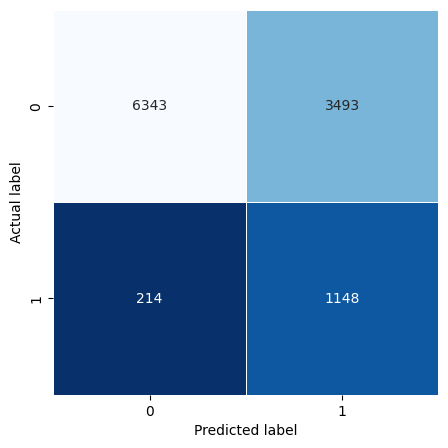

In [46]:
y_hat_test, auc_test, bs_test = class_prediction(x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold)

In [47]:
average_precision_score(y_test, y_hat_test)

0.2686677844753847

In [48]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

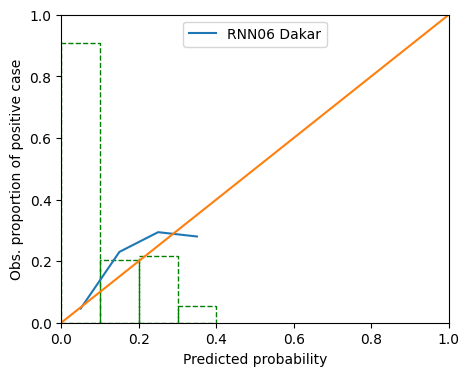

In [49]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"RNN0{lead_time} Dakar")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [50]:
#model.save(f'./Dakar-lt{lead_time}-lstm-t0-t-1.keras')
#dump(scaler, f'Dakar-lt{lead_time}-lstm-t0-t-1.bin', compress=True)

In [51]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [52]:
y_hat_train, auc_train, bs_train = class_prediction(x_train, y_train)

   1/1805 ━━━━━━━━━━━━━━━━━━━━ 57s 32ms/step

1805/1805 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


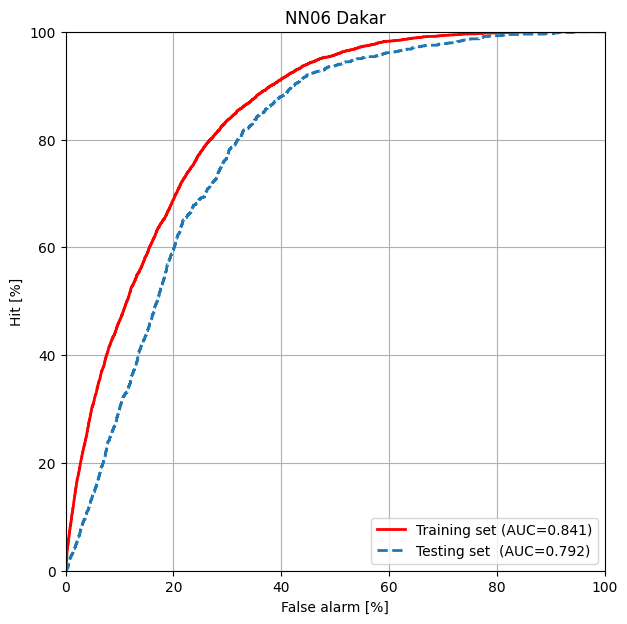

In [53]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train, y_hat_train, color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title(f"NN0{lead_time} Dakar")
plt.legend(loc='lower right');